# 03. Wyjaśnialność modeli XAI

W tej części projektu przeprowadzono analizę wyjaśnialności modeli. Celem jest sprawdzenie, które cechy najbardziej wpływają na predykcje oraz czy decyzje modeli są zgodne z intuicją dotyczącą problemu przewidywania cukrzycy.

Analiza obejmuje zarówno wyjaśnienia globalne, dotyczące ogólnego działania modelu, jak i wyjaśnienia lokalne, dotyczące pojedynczych predykcji.

## Regresja logistyczna

In [56]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [57]:
df = pd.read_csv("../data/diabetes.csv")

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [58]:
zero_columns = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

df_clean = df.copy()

for col in zero_columns:
    df_clean = df_clean[df_clean[col] != 0]

print("Oryginalny rozmiar danych:", df.shape)
print("Rozmiar po usunięciu wierszy z zerami:", df_clean.shape)
print("Usunięto obserwacji:", df.shape[0] - df_clean.shape[0])

Oryginalny rozmiar danych: (768, 9)
Rozmiar po usunięciu wierszy z zerami: (392, 9)
Usunięto obserwacji: 376


In [59]:
X = df_clean.drop("Outcome", axis=1)
y = df_clean["Outcome"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (392, 8)
y shape: (392,)


In [60]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    stratify = y,
    random_state = 42
)

X_train = X_train.astype(float)
X_test = X_test.astype(float)

In [61]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

pipeline_logistic = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=5000))
])

pipeline_logistic.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not wo

## Logistic Regression coefficients

Regresja logistyczna jest modelem z natury wyjaśnialnym. Po wytrenowaniu modelu można przeanalizować jego współczynniki, aby sprawdzić, które cechy zwiększają lub zmniejszają prawdopodobieństwo klasy 1, czyli występowania cukrzycy.

In [62]:
import pandas as pd
import matplotlib.pyplot as plt

model = pipeline_logistic.named_steps["model"]

coefficients = pd.Series(
    model.coef_[0],
    index=X_train.columns
)

coefficients.sort_values()

Insulin                    -0.136071
BloodPressure              -0.019115
SkinThickness               0.149897
Pregnancies                 0.197459
DiabetesPedigreeFunction    0.326984
Age                         0.361778
BMI                         0.392072
Glucose                     1.107309
dtype: float64

Model uznał, że na predykcję klasy 1, czyli cukrzycy, największe znaczenie mają:

Glucose — poziom glukozy
BMI — wskaźnik masy ciał
Pregnancies — liczba ciąż

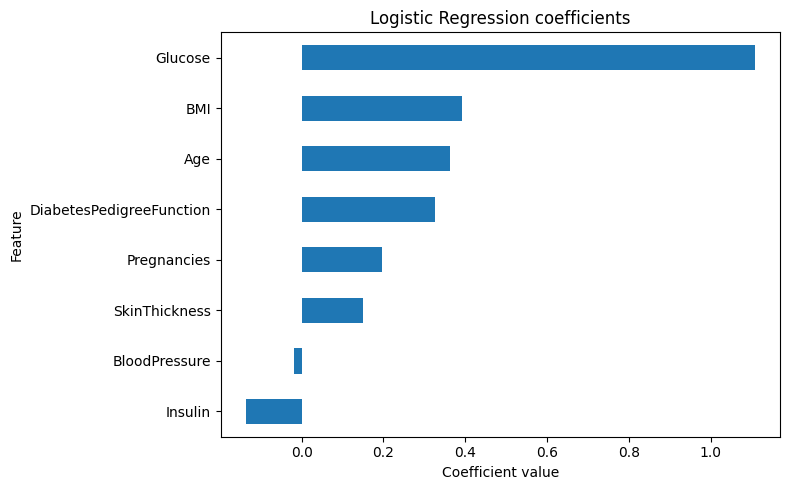

In [63]:
import os
import matplotlib.pyplot as plt

os.makedirs("../outputs/figures", exist_ok=True)

coefficients.sort_values().plot.barh(figsize=(8, 5))

plt.title("Logistic Regression coefficients")
plt.xlabel("Coefficient value")
plt.ylabel("Feature")
plt.tight_layout()

plt.savefig("../outputs/figures/logistic_coefficients.png", dpi=300)

plt.show()

Wykres potwierdza, że w modelu Logistic Regression największy dodatni wpływ na przewidywanie cukrzycy miały `Glucose` i `BMI`. Oznacza to, że model liniowy najsilniej wiązał te cechy ze wzrostem prawdopodobieństwa klasy 1 (cukrzycy).

## Permutation Importance - regresja logistyczna

In [64]:
from sklearn.inspection import permutation_importance
import pandas as pd

result_logistic = permutation_importance(
    pipeline_logistic,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="roc_auc"
)

importance_logistic_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance mean": result_logistic.importances_mean,
    "Importance std": result_logistic.importances_std
}).sort_values("Importance mean", ascending=False)

importance_logistic_df

,Feature,Importance mean,Importance std
1,Glucose,0.272496,0.038117
5,BMI,0.040131,0.010227
6,DiabetesPedigreeFunction,0.016473,0.006175
7,Age,0.014731,0.008178
0,Pregnancies,0.001524,0.004764
3,SkinThickness,0.000798,0.004237
2,BloodPressure,-0.001379,0.001145
4,Insulin,-0.003774,0.004166


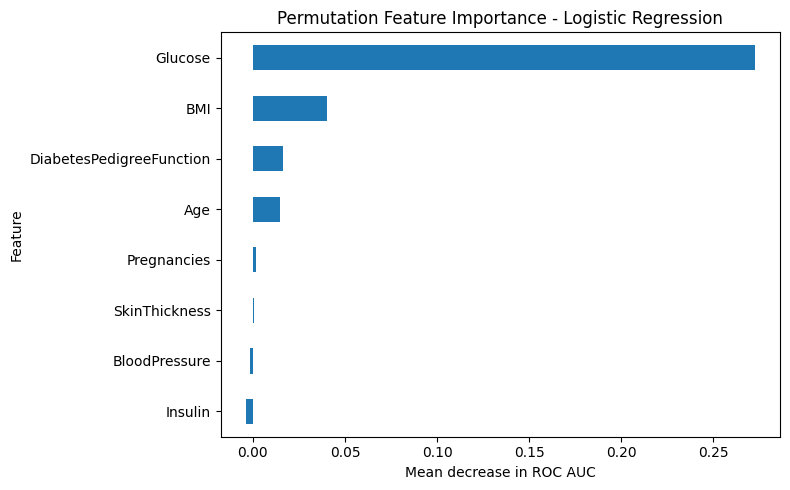

In [65]:
import os
import matplotlib.pyplot as plt

os.makedirs("../outputs/figures", exist_ok=True)

importance_logistic_df.sort_values("Importance mean").plot.barh(
    x="Feature",
    y="Importance mean",
    figsize=(8, 5),
    legend=False
)

plt.xlabel("Mean decrease in ROC AUC")
plt.ylabel("Feature")
plt.title("Permutation Feature Importance - Logistic Regression")
plt.tight_layout()

plt.savefig("../outputs/figures/permutation_importance_logistic.png", dpi=300)

plt.show()

Po losowym przemieszaniu wartości, największy spadek jakości wystąpił po przemieszaniu cechy `Glucose`, co oznacza, że była ona najważniejsza dla predykcji modelu.

Drugą ważną cechą było `BMI`, a następnie `Pregnancies`. Pozostałe cechy miały wyraźnie mniejszy wpływ na wynik modelu. Wynik ten jest spójny z interpretacją współczynników regresji logistycznej, ponieważ również tam `Glucose` i `BMI` należały do najważniejszych zmiennych.

## Random Forest

In [66]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

pipeline_rf = Pipeline([
    ("model", RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ))
])

pipeline_rf.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If 

## 3. Permutation Feature Importance dla Random Forest

Random Forest jest modelem złożonym, dlatego trudniej bezpośrednio odczytać sposób podejmowania decyzji. Z tego powodu zastosowano Permutation Importance, aby sprawdzić, które cechy najbardziej wpływają na jakość predykcji tego modelu.

In [67]:
from sklearn.inspection import permutation_importance
import pandas as pd

result_rf = permutation_importance(
    pipeline_rf,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="roc_auc"
)

importance_rf_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance mean": result_rf.importances_mean,
    "Importance std": result_rf.importances_std
}).sort_values("Importance mean", ascending=False)

importance_rf_df

,Feature,Importance mean,Importance std
1,Glucose,0.162663,0.033545
7,Age,0.020283,0.015080
4,Insulin,0.013752,0.017806
5,BMI,0.010196,0.010916
2,BloodPressure,0.004971,0.003636
0,Pregnancies,0.001814,0.015544
6,DiabetesPedigreeFunction,0.000581,0.016770
3,SkinThickness,-0.002395,0.005558


Wyniki Permutation Importance dla modelu Random Forest pokazują, że najważniejszą cechą pozostaje `Glucose`. Jej przemieszanie powoduje największy spadek wartości ROC AUC, co oznacza, że model silnie opiera się na poziomie glukozy podczas przewidywania cukrzycy.

Drugą najważniejszą cechą jest `BMI`, a następnie `Age`, `DiabetesPedigreeFunction` oraz `Pregnancies`. W porównaniu z regresją logistyczną Random Forest przypisuje większe znaczenie wiekowi. Może to wynikać z tego, że model drzewiasty potrafi uchwycić bardziej złożone zależności między cechami.

Cechy takie jak `BloodPressure` i `SkinThickness` mają bardzo niską ważność, co oznacza, że ich przemieszanie prawie nie pogarsza jakości predykcji modelu.

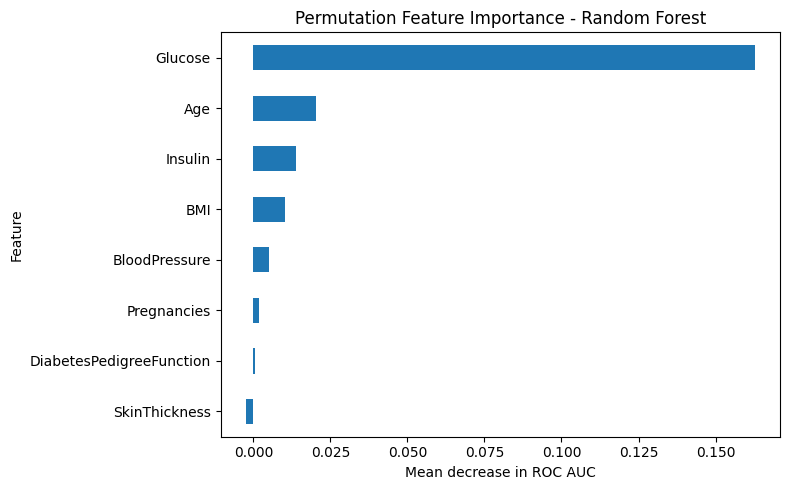

In [68]:
import os
import matplotlib.pyplot as plt

os.makedirs("../outputs/figures", exist_ok=True)

importance_rf_df.sort_values("Importance mean").plot.barh(
    x="Feature",
    y="Importance mean",
    figsize=(8, 5),
    legend=False
)

plt.xlabel("Mean decrease in ROC AUC")
plt.ylabel("Feature")
plt.title("Permutation Feature Importance - Random Forest")
plt.tight_layout()

plt.savefig("../outputs/figures/permutation_importance_random_forest.png", dpi=300)

plt.show()

Permutation Importance dla modelu Random Forest pokazuje, że najważniejszą cechą była `Glucose`. Po losowym przemieszaniu wartości tej cechy wynik ROC AUC spadał najbardziej, co oznacza, że model silnie wykorzystywał poziom glukozy przy klasyfikacji.

Drugą najważniejszą cechą było `BMI`, a następnie `Age`. W porównaniu z regresją logistyczną model Random Forest wyraźniej wykorzystuje również wiek pacjentki, co może wynikać z nieliniowego charakteru modelu drzewiastego.

Cechy `BloodPressure`, `Pregnancies`, `DiabetesPedigreeFunction`, `Insulin` i `SkinThickness` miały mniejszy wpływ na wynik modelu. Warto zauważyć, że `SkinThickness` uzyskało wartość bliską zeru lub lekko ujemną, co oznacza, że przemieszanie tej cechy nie pogorszyło jakości modelu.

## SHAP dla modelu Random Forest

In [14]:
!pip install shap


[notice] A new release of pip is available: 23.2.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [69]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [70]:
rf_model = pipeline_rf.named_steps["model"]

X_test_rf = X_test.copy()

In [71]:
X_train_rf = pd.DataFrame(
    columns=X_train.columns,
    index=X_train.index
)

X_test_rf = pd.DataFrame(
    columns=X_test.columns,
    index=X_test.index
)

## SHAP summary plot

In [72]:
import shap
import numpy as np
import matplotlib.pyplot as plt

rf_model = pipeline_rf.named_steps["model"]

X_test_rf = X_test.copy()

explainer_rf = shap.TreeExplainer(rf_model)

shap_values_rf = explainer_rf.shap_values(X_test_rf)

print(type(shap_values_rf))
print(np.array(shap_values_rf).shape)

<class 'numpy.ndarray'>
(79, 8, 2)


79 = liczba obserwacji w X_test
8 = liczba cech
2 = dwie klasy

SHAP class 1 shape: (79, 8)
X_test shape: (79, 8)


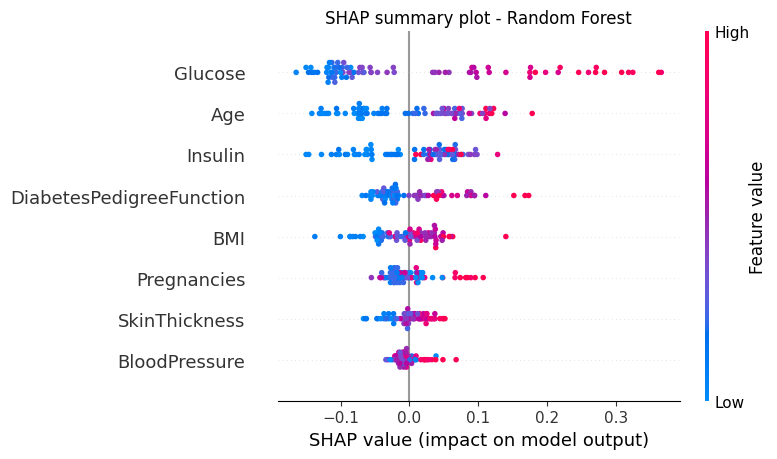

In [73]:
plt.close("all")

shap_values_class_1 = shap_values_rf[:, :, 1] # with diabeties

print("SHAP class 1 shape:", shap_values_class_1.shape)
print("X_test shape:", X_test_rf.shape)

shap.summary_plot(
    shap_values_class_1,
    X_test_rf,
    show=False
)

plt.title("SHAP summary plot - Random Forest")
plt.tight_layout()

plt.savefig("../outputs/figures/shap_summary_random_forest.png", dpi=300, bbox_inches="tight")

plt.show()

Wykres SHAP summary plot przedstawia globalny wpływ cech na predykcje modelu Random Forest. Najważniejszą cechą pozostaje `Glucose`, ponieważ jej wartości mają największy wpływ na przesuwanie predykcji modelu w stronę klasy 1 lub klasy 0.

Wysokie wartości `Glucose` znajdują się głównie po prawej stronie wykresu, co oznacza, że zwiększają przewidywane prawdopodobieństwo cukrzycy. Istotny wpływ mają również `Age`, `Insulin`, `DiabetesPedigreeFunction` oraz `BMI`.

Cechy znajdujące się niżej, takie jak `SkinThickness` i `BloodPressure`, mają mniejszy wpływ na decyzje modelu. Wynik SHAP jest spójny z pozostałymi metodami XAI, ponieważ ponownie wskazuje `Glucose` jako najważniejszą zmienną.

## SHAP bar plot

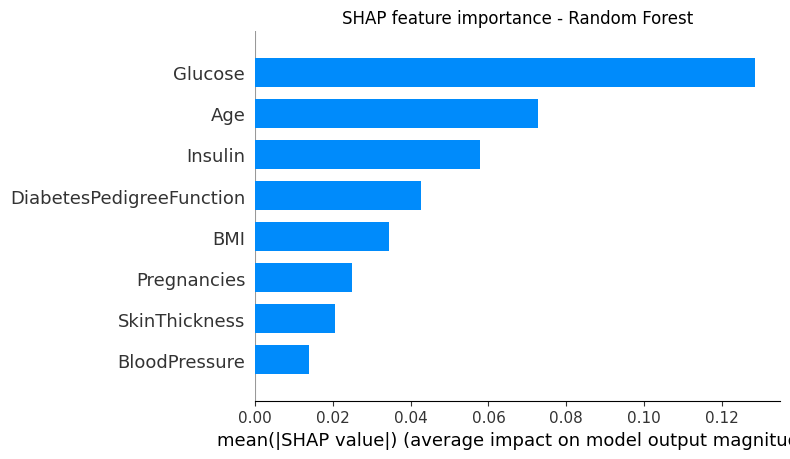

In [74]:
shap.summary_plot(
    shap_values_rf[:, :, 1],
    X_test_rf,
    plot_type="bar",
    show=False
)

plt.title("SHAP feature importance - Random Forest")
plt.tight_layout()
plt.savefig("../outputs/figures/shap_bar_random_forest.png", dpi=300, bbox_inches="tight")
plt.show()

Wykres słupkowy SHAP przedstawia globalny ranking cech według ich średniego wpływu na predykcje modelu Random Forest. Najważniejszą cechą ponownie okazała się `Glucose`, co potwierdza wcześniejsze wyniki uzyskane za pomocą Permutation Importance oraz interpretacji regresji logistycznej.

Wysoko w rankingu znalazły się również `BMI`, `Age` oraz `DiabetesPedigreeFunction`. Oznacza to, że model Random Forest często wykorzystywał te cechy przy przewidywaniu klasy 1, czyli cukrzycy.

Najmniejsze znaczenie miały `Insulin`, `SkinThickness` oraz `BloodPressure`. Wyniki SHAP są więc spójne z pozostałymi metodami XAI — najważniejsze zmienne to przede wszystkim `Glucose` i `BMI`.

## SHAP waterfall

In [75]:
i = 0

sample_df = X_test_rf.iloc[[i]]

prediction = rf_model.predict(sample_df)[0]
prediction_proba = rf_model.predict_proba(sample_df)[0, 1] # pierwsza osoba, prawdopodobieństwo klasy 1

print("Predicted class:", prediction)
print("Predicted probability of class 1:", prediction_proba)

Predicted class: 1
Predicted probability of class 1: 0.685


Dla wybranej obserwacji model Random Forest przewidział klasę 1, czyli cukrzycę, z prawdopodobieństwem około 69%.

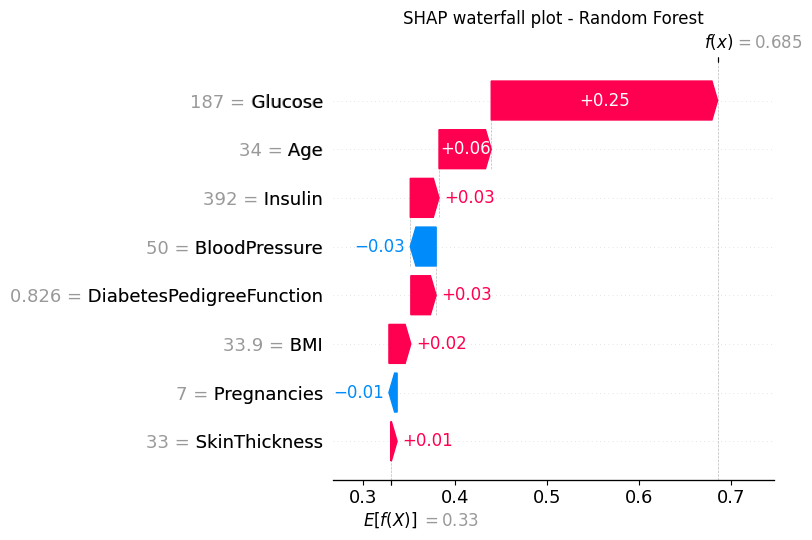

In [76]:
sample = X_test_rf.iloc[i]

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values_rf[i, :, 1],
        base_values=explainer_rf.expected_value[1],
        data=sample,
        feature_names=X_test_rf.columns
    ),
    show=False
)

plt.title("SHAP waterfall plot - Random Forest")
plt.tight_layout()

plt.savefig("../outputs/figures/shap_waterfall_random_forest.png", dpi=300, bbox_inches="tight")

plt.show()

Wykres waterfall przedstawia lokalne wyjaśnienie jednej predykcji modelu Random Forest. Dla analizowanej obserwacji model przewidział klasę 1, czyli cukrzycę, z prawdopodobieństwem około 0,69.

Największy dodatni wpływ na predykcję miała cecha `Glucose` o wartości 187, która wyraźnie zwiększyła przewidywane prawdopodobieństwo cukrzycy. Dodatni wpływ miały również `Age`, `Insulin`, `DiabetesPedigreeFunction`, `BMI` oraz `SkinThickness`, choć ich znaczenie było mniejsze niż wpływ poziomu glukozy.

Cechy `BloodPressure` oraz `Pregnancies` nieznacznie obniżały predykcję klasy 1 dla tej konkretnej obserwacji. Lokalna interpretacja potwierdza, że poziom glukozy był kluczowym czynnikiem wpływającym na decyzję modelu.

## LIME jako dodatkowa lokalna interpretacja

In [24]:
!pip install lime


[notice] A new release of pip is available: 23.2.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [77]:
from lime.lime_tabular import LimeTabularExplainer

In [78]:
explainer_lime = LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=X_train.columns,
    class_names=["No diabetes", "Diabetes"],
    mode="classification",
    discretize_continuous=True,
    random_state=42
)

In [79]:
i = 0

lime_exp = explainer_lime.explain_instance(
    data_row=X_test.iloc[i].values,
    predict_fn=pipeline_rf.predict_proba,
    num_features=8
)

lime_exp.as_list()

c:\Users\AS\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


[('Glucose > 142.00', 0.269772758664851),
 ('DiabetesPedigreeFunction > 0.68', 0.09404516565718113),
 ('27.00 < Age <= 36.00', 0.0923269846500369),
 ('Pregnancies > 5.00', 0.06287004231341838),
 ('Insulin > 188.00', 0.05938448139336878),
 ('33.20 < BMI <= 36.80', 0.03835017779117707),
 ('BloodPressure <= 62.00', -0.01322751814965917),
 ('29.00 < SkinThickness <= 37.00', 0.0127579983665602)]

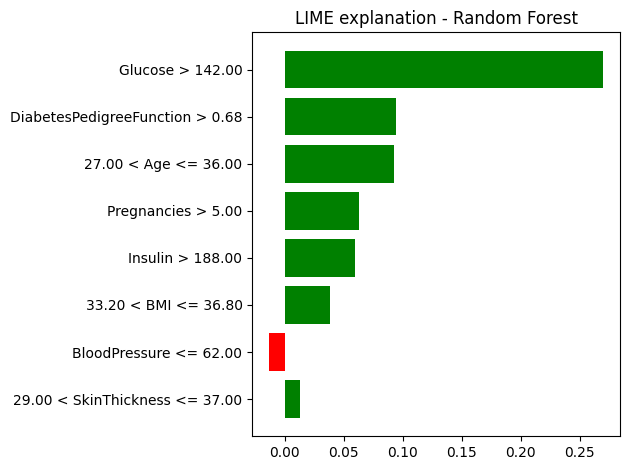

In [80]:
fig = lime_exp.as_pyplot_figure()

plt.title("LIME explanation - Random Forest")
plt.tight_layout()

plt.savefig("../outputs/figures/lime_random_forest.png", dpi=300, bbox_inches="tight")

plt.show()

LIME przedstawia lokalne wyjaśnienie jednej predykcji modelu Random Forest. W tym przypadku największy dodatni wpływ na predykcję miała cecha `Glucose > 142.00`. Oznacza to, że wysoki poziom glukozy silnie przesuwał decyzję modelu w stronę klasy 1. Dodatni wpływ miały również `DiabetesPedigreeFunction > 0.68`, przedział wieku `27.00 < Age <= 36.00`, `Insulin > 188.00`, `Pregnancies > 5.00` oraz `BMI` w przedziale `33.20 < BMI <= 36.80`.

Jedyną cechą o lekko ujemnym wpływie była `BloodPressure <= 62.00`, jednak jej wpływ był bardzo mały. Wynik LIME jest zgodny z wcześniejszymi metodami XAI, ponieważ ponownie wskazuje `Glucose` jako najważniejszą cechę wpływającą na predykcję.

## 5. PDP / ICE dla modelu Random Forest

PDP oraz ICE pozwalają sprawdzić, jak zmiana wartości wybranej cechy wpływa na predykcję modelu. PDP pokazuje średni wpływ cechy na wynik modelu, natomiast ICE pokazuje ten wpływ osobno dla pojedynczych obserwacji.

W tej części przeanalizowano cechę `Glucose`, ponieważ wcześniejsze metody XAI wskazały ją jako najważniejszą zmienną w modelu.

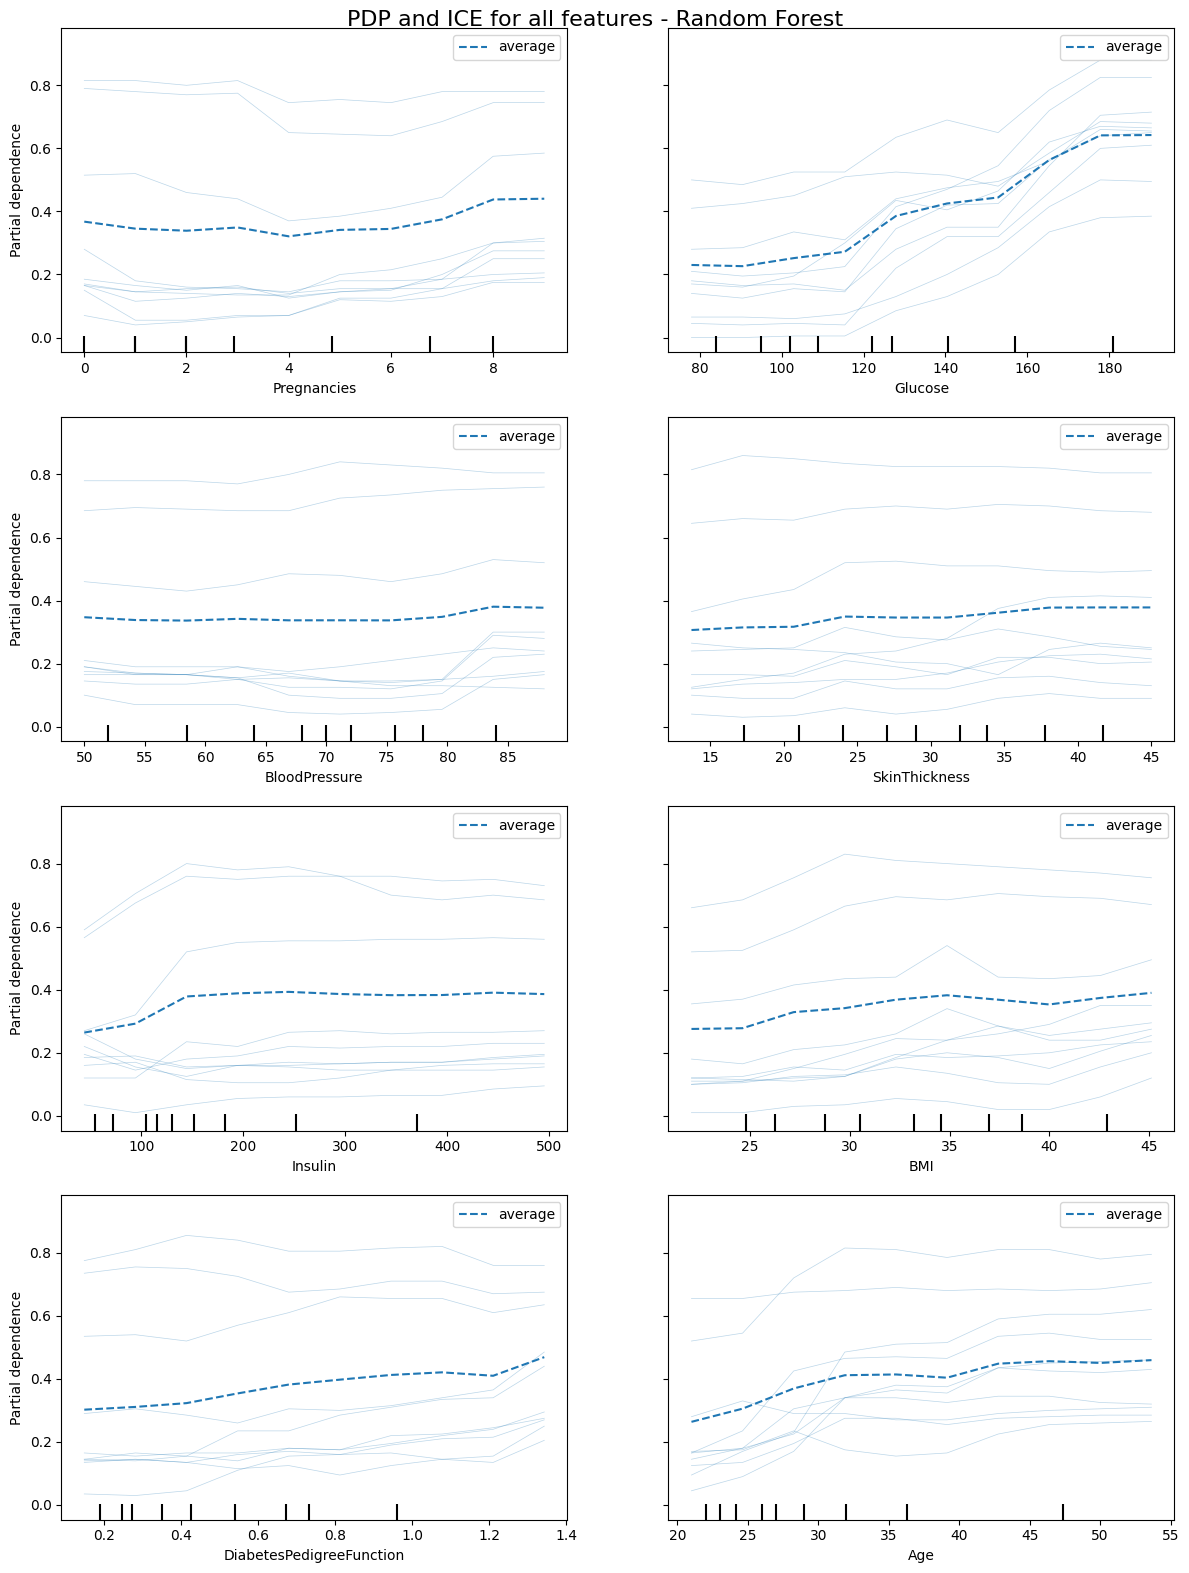

In [81]:
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

X_test_pdp = X_test.astype(float)
features = list(X_test_pdp.columns)

plt.close("all")

display = PartialDependenceDisplay.from_estimator(
    pipeline_rf,
    X_test_pdp,
    features=features,
    kind="both",
    response_method="predict_proba",
    target=1,
    subsample=10,
    random_state=42,
    grid_resolution=10,
    n_cols=2
)

display.figure_.set_size_inches(12, 16)
display.figure_.suptitle("PDP and ICE for all features - Random Forest", fontsize=16)

plt.tight_layout()
plt.show()

Zbiorczy wykres PDP/ICE przedstawia wpływ wszystkich cech na przewidywane prawdopodobieństwo klasy 1, czyli cukrzycy, w modelu Random Forest. Linia przerywana pokazuje średni wpływ danej cechy na predykcję modelu, natomiast jasne linie ICE pokazują wpływ tej cechy dla pojedynczych obserwacji.

Najbardziej wyraźny trend wzrostowy widoczny jest dla cechy `Glucose`. Oznacza to, że wraz ze wzrostem poziomu glukozy model przewiduje wyższe prawdopodobieństwo cukrzycy. Podobny, choć słabszy trend można zauważyć dla cech takich jak `BMI`, `Age` oraz `DiabetesPedigreeFunction`.

Dla części cech wpływ jest mniej jednoznaczny lub bardziej zależny od konkretnej obserwacji. Rozrzut linii ICE pokazuje, że model Random Forest wykorzystuje zależności nieliniowe oraz interakcje między cechami. Z tego powodu szczegółową interpretację przeprowadzono dodatkowo dla cechy `Glucose`, która była najbardziej istotna również w innych metodach XAI.

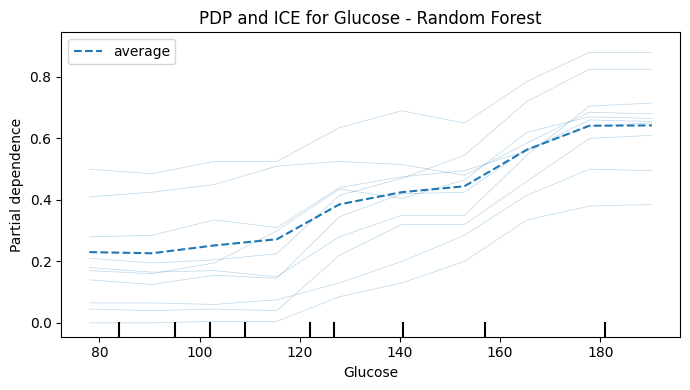

In [82]:
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 4))

PartialDependenceDisplay.from_estimator(
    pipeline_rf,
    X_test,
    features=["Glucose"],
    kind="both",
    response_method="predict_proba",
    target=1,
    subsample=10,
    random_state=42,
    grid_resolution=10,
    ax=ax
)

plt.title("PDP and ICE for Glucose - Random Forest")
plt.tight_layout()

plt.savefig("../outputs/figures/pdp_ice_glucose_random_forest.png", dpi=300)

plt.show()

Wykres PDP/ICE dla cechy `Glucose` pokazuje, że wraz ze wzrostem poziomu glukozy rośnie przewidywane prawdopodobieństwo klasy 1, czyli cukrzycy. Linia średnia PDP ma wyraźny trend rosnący, co oznacza, że model Random Forest traktuje wyższy poziom glukozy jako czynnik zwiększający ryzyko cukrzycy.

Linie ICE pokazują wpływ tej cechy dla pojedynczych obserwacji. Ich rozrzut oznacza, że wpływ glukozy nie jest identyczny dla wszystkich przypadków i może zależeć od pozostałych cech. Jest to typowe dla modeli drzewiastych, takich jak Random Forest.

## Dodatkowa interpretacja modelu SVC

Model SVC został wykorzystany jako trzeci model porównawczy. Aby uzupełnić analizę wyjaśnialności, zastosowano dla niego Permutation Importance, czyli metodę sprawdzającą, które cechy najbardziej wpływają na jakość predykcji modelu.

In [83]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

pipeline_svc = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(kernel="linear", probability=True))
])

pipeline_svc.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'


## Permutation Importance dla modelu SVC

In [84]:
from sklearn.inspection import permutation_importance
import pandas as pd
import matplotlib.pyplot as plt

result_svc = permutation_importance(
    pipeline_svc,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="roc_auc"
)

importance_svc_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance mean": result_svc.importances_mean,
    "Importance std": result_svc.importances_std
}).sort_values("Importance mean", ascending=False)

importance_svc_df

,Feature,Importance mean,Importance std
1,Glucose,0.306096,0.043537
5,BMI,0.026197,0.006941
7,Age,0.021118,0.010603
6,DiabetesPedigreeFunction,0.009869,0.007445
3,SkinThickness,0.005733,0.004537
0,Pregnancies,0.001016,0.003788
2,BloodPressure,0.000073,0.006170
4,Insulin,-0.002758,0.004756


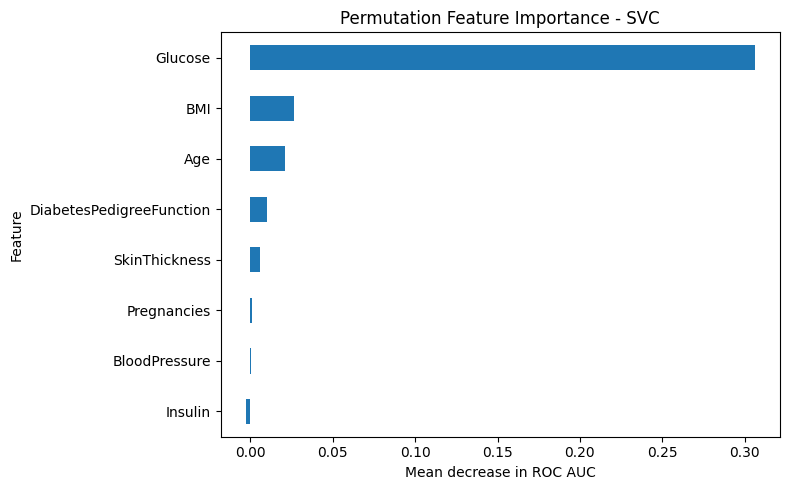

In [85]:
importance_svc_df.sort_values("Importance mean").plot.barh(
    x="Feature",
    y="Importance mean",
    figsize=(8, 5),
    legend=False
)

plt.xlabel("Mean decrease in ROC AUC")
plt.ylabel("Feature")
plt.title("Permutation Feature Importance - SVC")
plt.tight_layout()

plt.savefig("../outputs/figures/permutation_importance_svc.png", dpi=300)

plt.show()

Permutation Importance dla modelu SVC pokazuje, że najważniejszą cechą była `Glucose`. Jej losowe przemieszanie powodowało największy spadek wartości ROC AUC, co oznacza, że model SVC bardzo silnie opierał swoje decyzje na poziomie glukozy. Wynik SVC jest spójny z pozostałymi analizami w tym sensie, że ponownie wskazuje `Glucose` jako najważniejszą zmienną w przewidywaniu cukrzycy. Model SVC potraktowano jako model porównawczy, dlatego jego interpretacja ma charakter uzupełniający.

## SVC coefficients

In [86]:
svc_model = pipeline_svc.named_steps["model"]

svc_coefficients = pd.Series(
    svc_model.coef_[0],
    index=X_train.columns
)

svc_coefficients.sort_values()

Insulin                    -0.156382
BloodPressure              -0.089302
Pregnancies                 0.094181
SkinThickness               0.148512
BMI                         0.168435
DiabetesPedigreeFunction    0.176525
Age                         0.327888
Glucose                     0.909914
dtype: float64

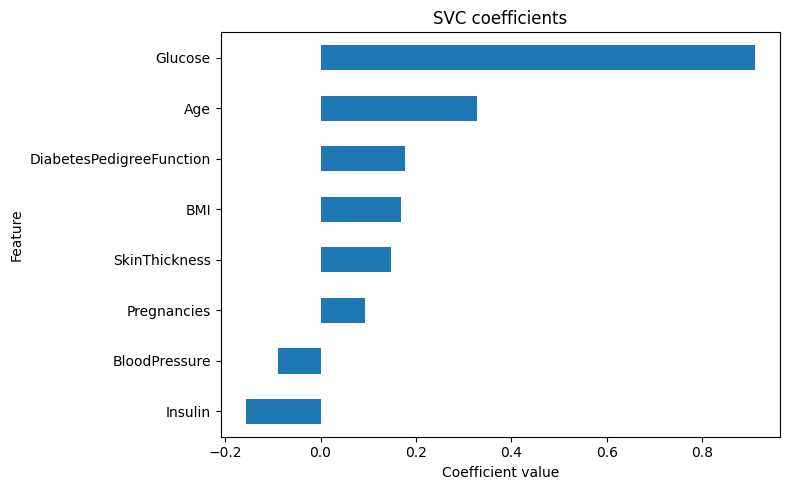

In [88]:
svc_coefficients.sort_values().plot.barh(figsize=(8, 5))

plt.title("SVC coefficients")
plt.xlabel("Coefficient value")
plt.ylabel("Feature")
plt.tight_layout()

plt.savefig("../outputs/figures/svc_coefficients.png", dpi=300)

plt.show()

Ponieważ w projekcie zastosowano SVC z liniowym kernelem, możliwa jest pomocnicza interpretacja współczynników modelu. Dodatnie współczynniki wskazują cechy, które przesuwają predykcję w stronę klasy 1, czyli cukrzycy, natomiast ujemne współczynniki przesuwają predykcję w stronę klasy 0.

Największy dodatni współczynnik uzyskała cecha `Glucose`, co oznacza, że także w modelu SVC poziom glukozy miał największy wpływ na przewidywanie klasy 1. Istotne dodatnie współczynniki miały również `Age`, `DiabetesPedigreeFunction` oraz `BMI`.

Interpretację współczynników SVC należy traktować jako uzupełniającą, ponieważ model SVC pełnił w projekcie przede wszystkim funkcję modelu porównawczego.

## Dobór metod XAI

W analizie XAI zastosowano metody dobrane do charakteru modeli. Dla modelu Logistic Regression wykorzystano interpretację współczynników oraz Permutation Importance, ponieważ jest to model liniowy i jego parametry można bezpośrednio analizować.

Dla modelu Random Forest zastosowano metody post-hoc: Permutation Importance, SHAP oraz PDP/ICE. Random Forest jest modelem złożonym, dlatego wymaga dodatkowych metod wyjaśnialności, które pozwalają sprawdzić, jakie cechy wpływają na predykcje oraz w jaki sposób zmiana wartości cechy wpływa na wynik modelu.

Model SVC został wykorzystany w części porównawczej jako trzeci model klasyfikacyjny. Wykonano dla niego dodatkową interpretację za pomocą Permutation Importance oraz współczynników modelu liniowego. Analiza ta miała charakter uzupełniający, ponieważ główną część XAI skoncentrowano na Logistic Regression oraz Random Forest. 